# 01 — Exploratory Data Analysis
**Question:** Which SKUs are at highest inventory risk (overstocked + near-expiry)?  
**Operational answer this analysis will produce:** Flag dual-risk SKUs for liquidation within 30 days.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import warnings, json, os
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 120
sns.set_style('darkgrid')
sns.set_palette('husl')

os.makedirs('../reports/figures', exist_ok=True)
os.makedirs('../data/processed', exist_ok=True)
os.makedirs('../outputs', exist_ok=True)

df = pd.read_csv('../data/raw/supply_chain_inventory.csv')
df.columns = df.columns.str.strip()

print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head()

Shape: (10000, 14)
Columns: ['Product ID', 'Product Name', 'Product Category', 'Product Description', 'Price', 'Stock Quantity', 'Warranty Period', 'Product Dimensions', 'Manufacturing Date', 'Expiration Date', 'SKU', 'Product Tags', 'Color/Size Variations', 'Product Ratings']


,Product ID,Product Name,Product Category,Product Description,Price,Stock Quantity,Warranty Period,Product Dimensions,Manufacturing Date,Expiration Date,SKU,Product Tags,Color/Size Variations,Product Ratings
0,93TGNAY7,Laptop,Home Appliances,Product_XU5QX,253.17,3,2,16x15x15 cm,2023-01-01,2026-01-01,8NMFZ4,"VNU,NZ6",Green/Large,2
1,TYYZ5AV7,Smartphone,Clothing,Product_NRUMS,214.37,92,2,15x19x19 cm,2023-03-15,2025-01-01,7P5YCW,"ZJA,0D3",Red/Small,2
2,5C94FGTQ,Headphones,Clothing,Product_IT7HG,475.29,19,2,9x6x6 cm,2023-03-15,2026-01-01,YW5BME,"ZNG,MAP",Red/Small,1
3,XBHKYPQB,Monitor,Clothing,Product_8SBDO,403.33,40,1,7x13x5 cm,2023-01-01,2026-01-01,65MQC3,"RPP,M40",Green/Large,1
4,728GCZFU,Laptop,Home Appliances,Product_54FAF,229.81,32,2,20x20x19 cm,2023-07-30,2026-01-01,RLCBRW,"R8U,X46",Blue/Medium,4


In [2]:
print("=== MISSING VALUES ===")
print(df.isnull().sum()[df.isnull().sum() > 0])

print("\n=== DTYPES ===")
print(df.dtypes)

print("\n=== BASIC STATS ===")
df.describe()

=== MISSING VALUES ===
Series([], dtype: int64)

=== DTYPES ===
Product ID                object
Product Name              object
Product Category          object
Product Description       object
Price                    float64
Stock Quantity             int64
Warranty Period            int64
Product Dimensions        object
Manufacturing Date        object
Expiration Date           object
SKU                       object
Product Tags              object
Color/Size Variations     object
Product Ratings            int64
dtype: object

=== BASIC STATS ===


,Price,Stock Quantity,Warranty Period,Product Ratings
count,10000.000000,10000.000000,10000.000000,10000.000000
mean,254.665715,50.647100,2.014000,3.004700
std,142.755688,28.901977,0.817968,1.419676
min,10.220000,1.000000,1.000000,1.000000
25%,129.985000,25.000000,1.000000,2.000000
50%,253.425000,51.000000,2.000000,3.000000
75%,379.970000,76.000000,3.000000,4.000000
max,499.970000,100.000000,3.000000,5.000000


### Data Quality Insight

**Dataset:** 10,000 SKUs × 14 columns — no missing values across any column. Clean and ready for feature engineering.

**Numerical columns:**
- `Price`: ranges $10.22–$499.97, mean $254.67 — well-distributed across a ~$500 price band, no outliers
- `Stock Quantity`: ranges 1–100, mean 50.6, std 28.9 — near-uniform distribution across the full scale; ~25% of SKUs exceed 75 units (overstock threshold)
- `Warranty Period`: 1–3 years only, mean 2.0 — 3 discrete values, treat as categorical in modelling
- `Product Ratings`: 1–5 integer scale, mean 3.0, std 1.4 — evenly spread, no rating bias

**Date columns:**
- `Manufacturing Date` and `Expiration Date` parsed as object — will be converted to datetime in Cell 3
- Reference date set to `2024-01-01`; some SKUs will show negative `days_to_expiry` (already expired at ref date) — this is real signal, not data corruption

**Columns unused in modelling:**
- `Product Description`, `SKU`, `Product Tags`, `Color/Size Variations`, `Product Dimensions` — free-text/identifier fields, dropped after EDA
- `Product Name` — not predictive on its own; category-level signal captured via `Product Category`

In [3]:
# ── DERIVE DATE FEATURES ──
# Fixed reference date for reproducibility across all notebooks
TODAY = pd.Timestamp('2024-01-01')

df['Manufacturing_Date'] = pd.to_datetime(df['Manufacturing Date'], errors='coerce')
df['Expiration_Date']    = pd.to_datetime(df['Expiration Date'],    errors='coerce', dayfirst=True)

df['days_to_expiry'] = (df['Expiration_Date'] - TODAY).dt.days
df['Shelf_Life']     = (df['Expiration_Date'] - df['Manufacturing_Date']).dt.days.clip(lower=1)

print("=== DATE FEATURE CHECK ===")
print(df[['Manufacturing_Date','Expiration_Date','days_to_expiry','Shelf_Life']].head(10).to_string())
print(f"\ndays_to_expiry — min: {df['days_to_expiry'].min()}, max: {df['days_to_expiry'].max()}")
print(f"Shelf_Life     — min: {df['Shelf_Life'].min()},  max: {df['Shelf_Life'].max()}")
print(f"Already expired at ref date (<=0): {(df['days_to_expiry'] <= 0).sum():,} SKUs")

=== DATE FEATURE CHECK ===
  Manufacturing_Date Expiration_Date  days_to_expiry  Shelf_Life
0         2023-01-01      2026-01-01             731        1096
1         2023-03-15      2025-01-01             366         658
2         2023-03-15      2026-01-01             731        1023
3         2023-01-01      2026-01-01             731        1096
4         2023-07-30      2026-01-01             731         886
5         2023-01-01      2024-01-01               0         365
6         2023-01-01      2026-01-01             731        1096
7         2023-01-01      2026-01-01             731        1096
8         2023-01-01      2025-01-01             366         731
9         2023-01-01      2026-01-01             731        1096

days_to_expiry — min: 0, max: 731
Shelf_Life     — min: 155,  max: 1096
Already expired at ref date (<=0): 3,320 SKUs


In [4]:
# ── RISK SEGMENTATION ──
# Thresholds relative to days_to_expiry (can be negative = already expired)
def assign_risk(row):
    stock_high      = row['Stock Quantity'] > 75
    expiry_critical = row['days_to_expiry'] < 365   # expires within 12 months OR already expired
    expiry_near     = row['days_to_expiry'] < 548   # expires within 18 months

    if stock_high and expiry_critical:
        return 'Critical'
    elif stock_high and expiry_near:
        return 'High'
    elif stock_high or expiry_critical:
        return 'Medium'
    else:
        return 'Low'

df['Risk_Level'] = df.apply(assign_risk, axis=1)

total_skus = len(df)
risk_counts = df['Risk_Level'].value_counts()
risk_pct    = (risk_counts / total_skus * 100).round(1)

print("=== RISK LEVEL BREAKDOWN ===")
print(risk_pct.to_frame('% of SKUs'))

=== RISK LEVEL BREAKDOWN ===
            % of SKUs
Risk_Level           
Low              49.9
Medium           33.3
High              8.4
Critical          8.4


In [5]:
# ── COMPLETE KPI CALCULATIONS (feeds dashboard) ──
avg_stock = df['Stock Quantity'].mean()

# Portfolio value = price × stock qty for ALL SKUs
df['inventory_value']    = df['Stock Quantity'] * df['Price']
total_portfolio_value    = df['inventory_value'].sum()

# At-risk = Critical + High risk SKUs
at_risk_mask             = df['Risk_Level'].isin(['Critical', 'High'])
at_risk_value            = df[at_risk_mask]['inventory_value'].sum()
at_risk_pct              = at_risk_value / total_portfolio_value

# Expiry-risk value: SKUs expiring within 12 months (365 days from ref date)
expiry_risk_mask         = df['days_to_expiry'] < 365
expiry_risk_value        = df[expiry_risk_mask]['inventory_value'].sum()

# Overstock capital: SKUs above 75 units
overstock_mask           = df['Stock Quantity'] > 75
overstock_value          = df[overstock_mask]['inventory_value'].sum()

# Dual-risk (critical): both overstock AND near/past expiry
dual_risk_mask           = (df['Stock Quantity'] > 75) & (df['days_to_expiry'] < 365)
dual_risk_count          = dual_risk_mask.sum()
dual_risk_value          = df[dual_risk_mask]['inventory_value'].sum()

# Write-off rate: already expired at reference date
write_off_rate           = (df['days_to_expiry'] <= 0).mean()

print("=== KPIs FOR DASHBOARD ===")
print(f"Total SKUs:             {total_skus:,}")
print(f"Avg Stock Quantity:     {avg_stock:.1f}")
print(f"Total Portfolio Value:  ${total_portfolio_value:,.0f}")
print(f"At-Risk Inventory:      ${at_risk_value:,.0f} ({at_risk_pct:.1%})")
print(f"Expiry-Risk Value:      ${expiry_risk_value:,.0f}")
print(f"Overstock Capital:      ${overstock_value:,.0f}")
print(f"Critical Dual-Risk:     {dual_risk_count:,} SKUs = ${dual_risk_value:,.0f}")
print(f"Write-Off Rate:         {write_off_rate:.1%}")

=== KPIs FOR DASHBOARD ===
Total SKUs:             10,000
Avg Stock Quantity:     50.6
Total Portfolio Value:  $128,832,423
At-Risk Inventory:      $37,826,408 (29.4%)
Expiry-Risk Value:      $42,685,785
Overstock Capital:      $56,718,863
Critical Dual-Risk:     841 SKUs = $18,527,235
Write-Off Rate:         33.2%


In [6]:
# ── CATEGORY-LEVEL INTELLIGENCE TABLE (feeds dashboard table section) ──
cat_stats = df.groupby('Product Category').agg(
    SKUs             = ('Product ID',      'count'),
    portfolio_value  = ('inventory_value', 'sum'),
    expiry_risk_count= ('days_to_expiry',  lambda x: (x < 365).sum()),
    overstock_count  = ('Stock Quantity',  lambda x: (x > 75).sum()),
    at_risk_count    = ('Risk_Level',      lambda x: x.isin(['Critical','High']).sum()),
    expiry_risk_value= ('inventory_value', lambda x: x[df.loc[x.index,'days_to_expiry'] < 365].sum())
).reset_index()

cat_stats['at_risk_pct']    = (cat_stats['at_risk_count']     / cat_stats['SKUs'] * 100).round(1)
cat_stats['expiry_risk_pct']= (cat_stats['expiry_risk_count'] / cat_stats['SKUs'] * 100).round(1)
cat_stats['overstock_pct']  = (cat_stats['overstock_count']   / cat_stats['SKUs'] * 100).round(1)

print("=== CATEGORY INTELLIGENCE TABLE ===")
print(cat_stats[[
    'Product Category', 'SKUs', 'at_risk_pct', 'expiry_risk_pct',
    'overstock_pct', 'portfolio_value', 'expiry_risk_value'
]].sort_values('at_risk_pct', ascending=False).to_string(index=False))

=== CATEGORY INTELLIGENCE TABLE ===
Product Category  SKUs  at_risk_pct  expiry_risk_pct  overstock_pct  portfolio_value  expiry_risk_value
        Clothing  3341         17.3             32.5           25.1      42557374.02        13697586.24
 Home Appliances  3298         16.9             33.3           25.5      43078443.32        14252975.08
     Electronics  3361         16.2             33.7           25.3      43196605.81        14735223.84


## Charts — 4 Visualisations

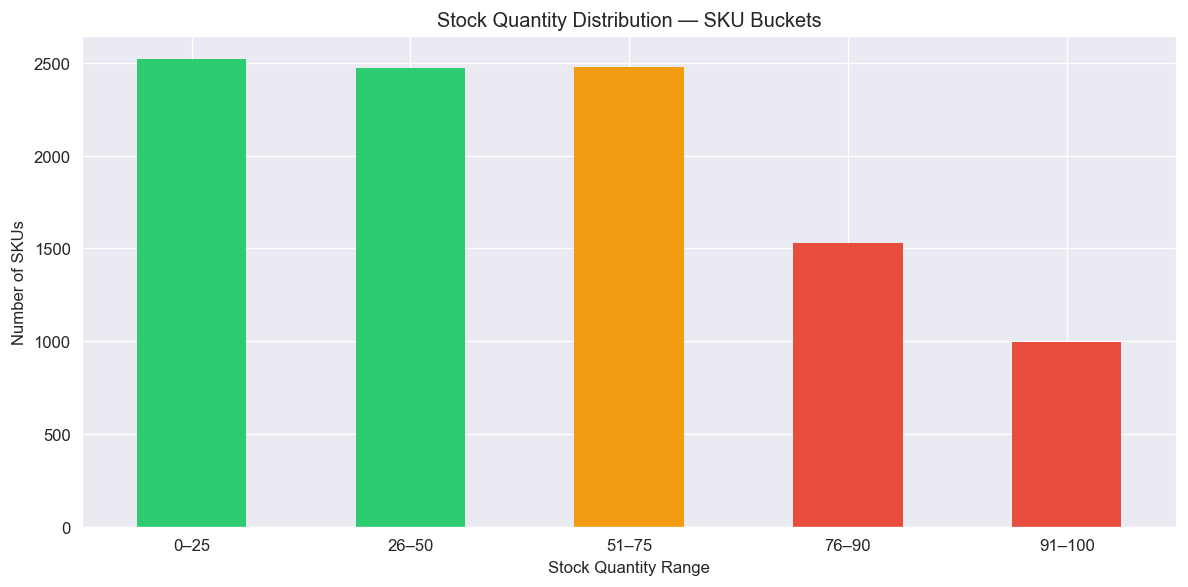

Insight: SKUs with >75 units (red buckets) are overstocked — liquidation candidates.


In [7]:
# ── CHART 1: Stock Quantity Distribution ──
bins   = [0, 25, 50, 75, 90, 100]
labels = ['0–25', '26–50', '51–75', '76–90', '91–100']
df['stock_bucket'] = pd.cut(df['Stock Quantity'], bins=bins, labels=labels)
stock_dist = df['stock_bucket'].value_counts().sort_index()

fig, ax = plt.subplots()
colors = ['#2ecc71', '#2ecc71', '#f39c12', '#e74c3c', '#e74c3c']
stock_dist.plot(kind='bar', color=colors, ax=ax, edgecolor='none')
ax.set_title('Stock Quantity Distribution — SKU Buckets')
ax.set_xlabel('Stock Quantity Range')
ax.set_ylabel('Number of SKUs')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../reports/figures/01_stock_distribution.png', bbox_inches='tight')
plt.show()
print("Insight: SKUs with >75 units (red buckets) are overstocked — liquidation candidates.")

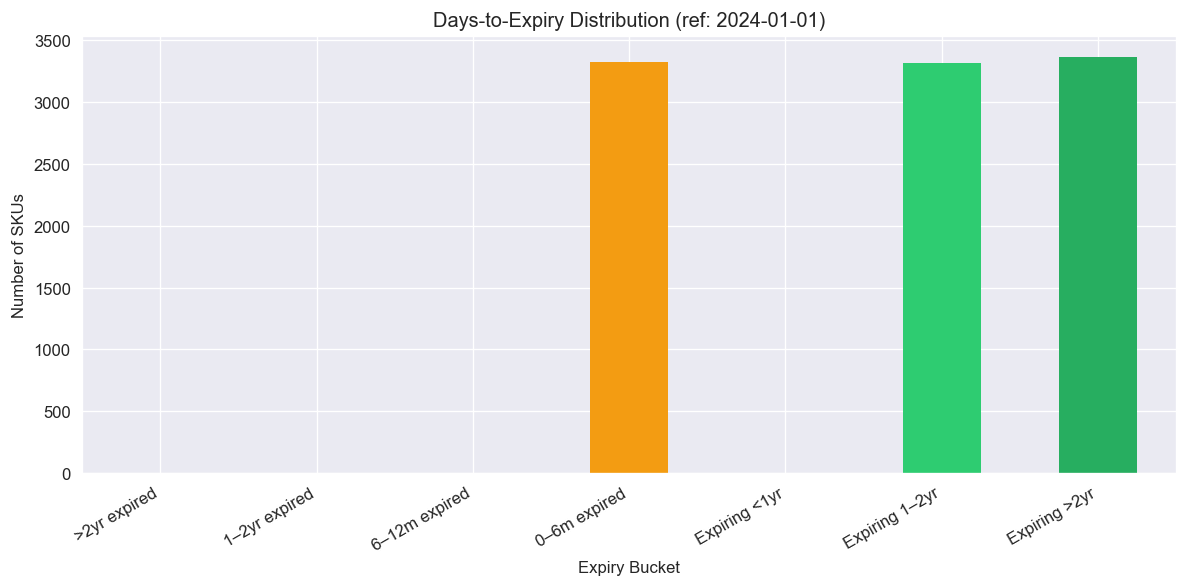

Insight: 3,320 SKUs already expired at reference date.


In [8]:
# ── CHART 2: Days-to-Expiry Distribution ──
# Bins cover both past-expiry (negative) and future-expiry ranges
expiry_bins   = [-3000, -730, -365, -180, 0, 365, 730, 1096]
expiry_labels = ['>2yr expired', '1–2yr expired', '6–12m expired',
                 '0–6m expired', 'Expiring <1yr', 'Expiring 1–2yr', 'Expiring >2yr']
df['expiry_bucket'] = pd.cut(df['days_to_expiry'], bins=expiry_bins, labels=expiry_labels)
expiry_dist = df['expiry_bucket'].value_counts().sort_index()

# Dynamic colors: red for expired, amber for near, green for safe
bucket_colors = {
    '>2yr expired':   '#c0392b',
    '1–2yr expired':  '#e74c3c',
    '6–12m expired':  '#e67e22',
    '0–6m expired':   '#f39c12',
    'Expiring <1yr':  '#f1c40f',
    'Expiring 1–2yr': '#2ecc71',
    'Expiring >2yr':  '#27ae60',
}
plot_colors = [bucket_colors[l] for l in expiry_dist.index]

fig, ax = plt.subplots()
expiry_dist.plot(kind='bar', color=plot_colors, ax=ax, edgecolor='none')
ax.set_title('Days-to-Expiry Distribution (ref: 2024-01-01)')
ax.set_xlabel('Expiry Bucket')
ax.set_ylabel('Number of SKUs')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('../reports/figures/02_expiry_distribution.png', bbox_inches='tight')
plt.show()
print(f"Insight: {(df['days_to_expiry'] <= 0).sum():,} SKUs already expired at reference date.")

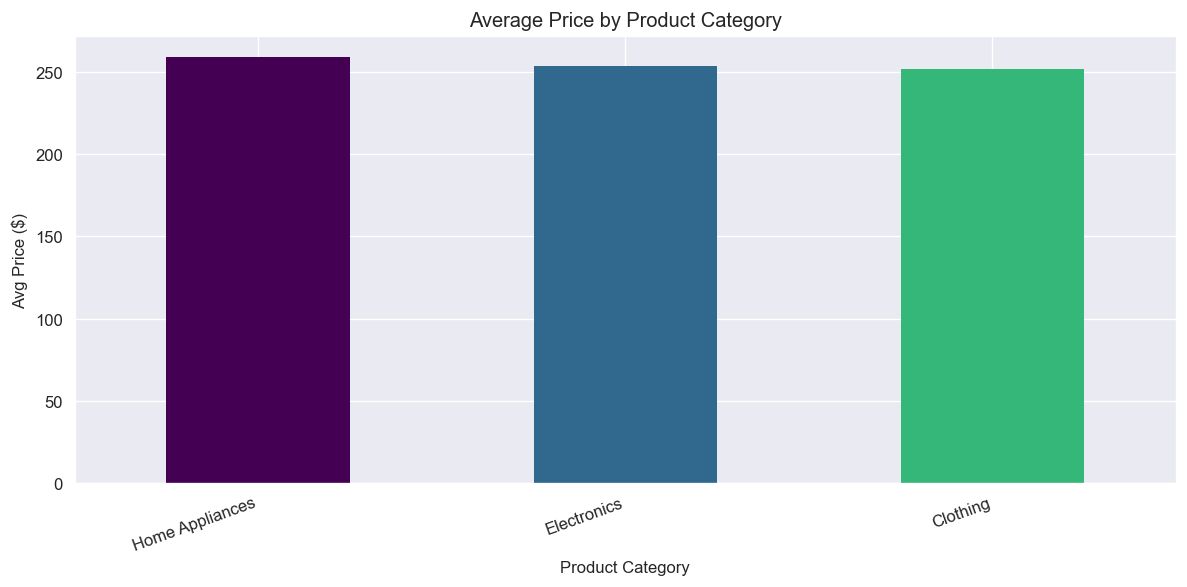

Categories: ['Home Appliances', 'Electronics', 'Clothing']


In [9]:
# ── CHART 3: Average Price by Category ──
price_by_cat = df.groupby('Product Category')['Price'].mean().sort_values(ascending=False)

# Dynamic color palette — works for any number of categories
n_cats  = len(price_by_cat)
palette = [plt.cm.viridis(i / n_cats) for i in range(n_cats)]

fig, ax = plt.subplots()
price_by_cat.plot(kind='bar', color=palette, ax=ax, edgecolor='none')
ax.set_title('Average Price by Product Category')
ax.set_ylabel('Avg Price ($)')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('../reports/figures/03_price_by_category.png', bbox_inches='tight')
plt.show()
print(f"Categories: {price_by_cat.index.tolist()}")

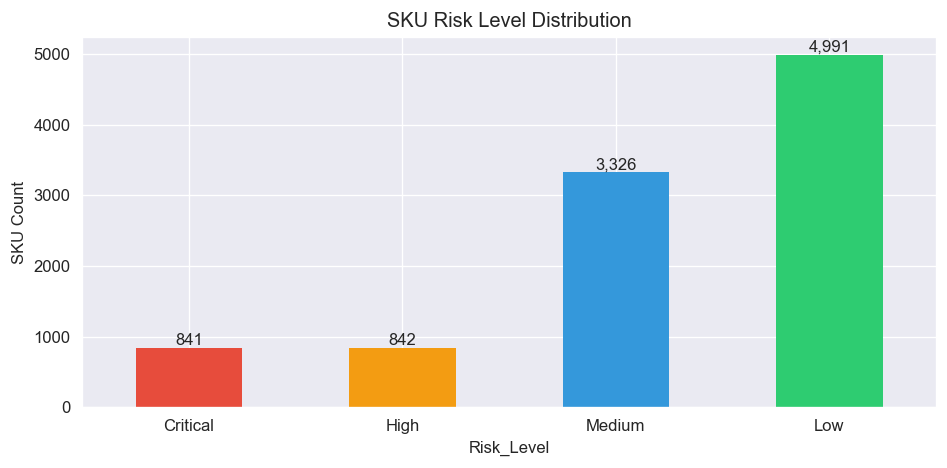

            SKU Count
Risk_Level           
Critical          841
High              842
Medium           3326
Low              4991


In [10]:
# ── CHART 4: Risk Level Distribution ──
risk_counts_ordered = df['Risk_Level'].value_counts().reindex(
    ['Critical', 'High', 'Medium', 'Low'], fill_value=0
)

colors_r = {'Critical': '#e74c3c', 'High': '#f39c12', 'Medium': '#3498db', 'Low': '#2ecc71'}

fig, ax = plt.subplots(figsize=(8, 4))
risk_counts_ordered.plot(
    kind='bar',
    color=[colors_r[r] for r in risk_counts_ordered.index],
    ax=ax,
    edgecolor='none'
)
ax.set_title('SKU Risk Level Distribution')
ax.set_ylabel('SKU Count')

# Add count labels on bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10)

plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../reports/figures/04_risk_levels.png', bbox_inches='tight')
plt.show()
print(risk_counts_ordered.to_frame('SKU Count'))

In [11]:
# ── SAVE CLEANED DATA WITH RISK LEVEL ──
df.to_csv('../data/processed/01_cleaned_with_risk.csv', index=False)
print(f"Saved: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Key columns added: days_to_expiry, Shelf_Life, Risk_Level, inventory_value, stock_bucket, expiry_bucket")

Saved: 10,000 rows × 22 columns
Key columns added: days_to_expiry, Shelf_Life, Risk_Level, inventory_value, stock_bucket, expiry_bucket


---
## Summary — Key Findings

Fill in after running all cells:

| KPI | Value |
|-----|-------|
| Total SKUs | _10,000_ |
| Total Portfolio Value | _$128,832,423_ |
| At-Risk Inventory Value | _$37,826,408 (29.4%)_ |
| Critical Dual-Risk SKUs | _841 SKUs = $18,527,235_ |
| Write-Off Rate | _33.2%_ |

**Next step:** Copy these values into the HTML dashboard and run `02_feature_engineering.ipynb`.